In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import numpy as np

In [3]:
df= pd.read_excel('dataset_20260430.csv.xlsx')

### Understanding Data

In [4]:
df.shape

(50000, 13)

In [5]:
df.head()

,user_id,registration_timestamp,email_domain,age,gender,job_title,education_level,is_smoker,is_drinker,os,device_type,registration_duration_ms,is_fraud
0,e0adb1b0-7300-4f1c-a6c6-6d166cdfa2a6,2025-01-01T00:00:56.670990,hotmail.com,68,F,Mid-Level,High School,False,True,windows,desktop,14544.058189,False
1,8d135521-b7b3-42bf-a6c8-1a9fe078e571,2025-01-01T00:01:03.080025,gmail.com,57,F,Mid-Level,Bachelors,False,False,windows,desktop,11601.448980,False
2,82743fb3-4d4a-4ea4-a00e-92669db6bab0,2025-01-01T00:04:09.922874,hotmail.com,26,M,Mid-Level,Bachelors,False,False,ios,mobile,14883.372316,False
3,78248957-662c-464c-92c6-b318ba99f6bb,2025-01-01T00:04:49.539518,gmail.com,56,F,Mid-Level,Bachelors,False,False,windows,desktop,15336.277831,False
4,f1bbc4c9-92f5-498b-9482-1e9bd02d3d8e,2025-01-01T00:04:56.149444,gmail.com,33,M,Mid-Level,NaN,False,True,windows,desktop,15388.668264,False


In [6]:
df.dtypes

user_id                      object
registration_timestamp       object
email_domain                 object
age                           int64
gender                       object
job_title                    object
education_level              object
is_smoker                      bool
is_drinker                     bool
os                           object
device_type                  object
registration_duration_ms    float64
is_fraud                       bool
dtype: object

In [7]:
df['is_fraud'].value_counts()

is_fraud
False    47500
True      2500
Name: count, dtype: int64

### 5% positive class ( Fraud cases) - High Imbalance data 

In [8]:
df['registration_duration_ms'].describe()

count    50000.000000
mean     14997.066660
std       1998.664995
min       7242.293232
25%      13647.245718
50%      14998.195547
75%      16342.044272
max      23242.858992
Name: registration_duration_ms, dtype: float64

In [9]:
df.isna().sum()

user_id                        0
registration_timestamp         0
email_domain                   0
age                            0
gender                         0
job_title                      0
education_level             4895
is_smoker                      0
is_drinker                     0
os                             0
device_type                    0
registration_duration_ms       0
is_fraud                       0
dtype: int64

In [10]:
df['registration_timestamp'] = pd.to_datetime(df['registration_timestamp'])

In [12]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = [
    '0-18',
    '19-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '65+'
]

df['age_bucket'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [13]:
df['age_bucket'].value_counts()

age_bucket
56-65    9693
36-45    9634
26-35    9580
46-55    9519
19-25    6667
65+      3917
0-18      990
Name: count, dtype: int64

In [22]:
df['registration_date'] = df['registration_timestamp'].dt.date

daily_stats = (
    df.groupby('registration_date')
      .agg(
          total_users=('is_fraud','count'),
          fraud_users=('is_fraud','sum')
      )
      .reset_index()
)

daily_stats['fraud_rate'] = (
    daily_stats['fraud_users']*100 /
    daily_stats['total_users']
)

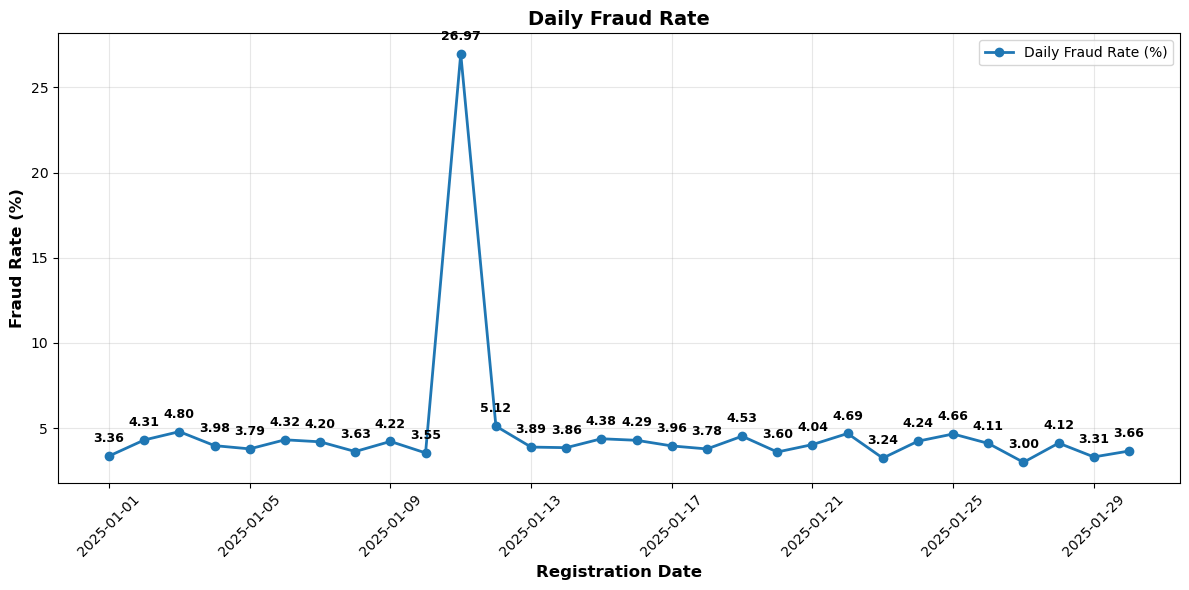

In [30]:

plt.figure(figsize=(12,8))

plt.plot(
    daily_stats['registration_date'],
    daily_stats['fraud_rate'],
    marker='o',
    linewidth=2,
    label='Daily Fraud Rate (%)'
)

# Add values on each point
for x, y in zip(
    daily_stats['registration_date'],
    daily_stats['fraud_rate']
):
    plt.annotate(
        f'{y:.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.xticks(rotation=45)

plt.xlabel(
    'Registration Date',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Fraud Rate (%)',
    fontsize=12,
    fontweight='bold'
)

plt.title(
    'Daily Fraud Rate',
    fontsize=14,
    fontweight='bold'
)

plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Daily Fraud Rate Analysis

The daily fraud rate remained largely stable throughout the observation period, fluctuating between **3% and 5%** on most days. However, a significant anomaly was observed on **11-Jan-2025**, where the fraud rate surged to approximately **27%**, representing more than a **5x increase** over the normal baseline.

Key observations:

- Baseline fraud rate across most days: **3%–5%**
- Peak fraud rate observed on **11-Jan-2025: 27%**
- Fraud rate returned to normal levels immediately after the spike, indicating a short-lived anomalous event rather than a sustained trend.
- The abrupt increase followed by an immediate normalization suggests the possibility of:
  - Coordinated fraudulent registrations
  - Automated/bot-driven account creation
  - Exploitation of a temporary vulnerability
  - A targeted fraud campaign during a specific time window

### Identified Anomalous Period

Based on the temporal analysis, the primary anomalous period is identified as:

**09-Jan-2025 to 13-Jan-2025**

with **11-Jan-2025** being the peak anomaly date.

### Interpretation

The fraud concentration observed during this period is significantly higher than the expected background fraud rate and warrants further investigation into user characteristics such as registration time, email domains, job titles, education levels, device information, and other behavioral attributes associated with registrations occurring during the anomalous window.

In [31]:
df['registration_date'] = df['registration_timestamp'].dt.date

daily_stats = (
    df.groupby('registration_date')
      .agg(
          total_users=('is_fraud','count'),
          fraud_users=('is_fraud','sum')
      )
      .reset_index()
)

daily_stats['fraud_rate'] = (
    daily_stats['fraud_users'] /
    daily_stats['total_users']
) * 100

# Cumulative fraud users
daily_stats['cum_fraud_users'] = (
    daily_stats['fraud_users'].cumsum()
)

# Cumulative fraud %
daily_stats['cum_fraud_pct'] = (
    daily_stats['cum_fraud_users']
    / daily_stats['fraud_users'].sum()
) * 100

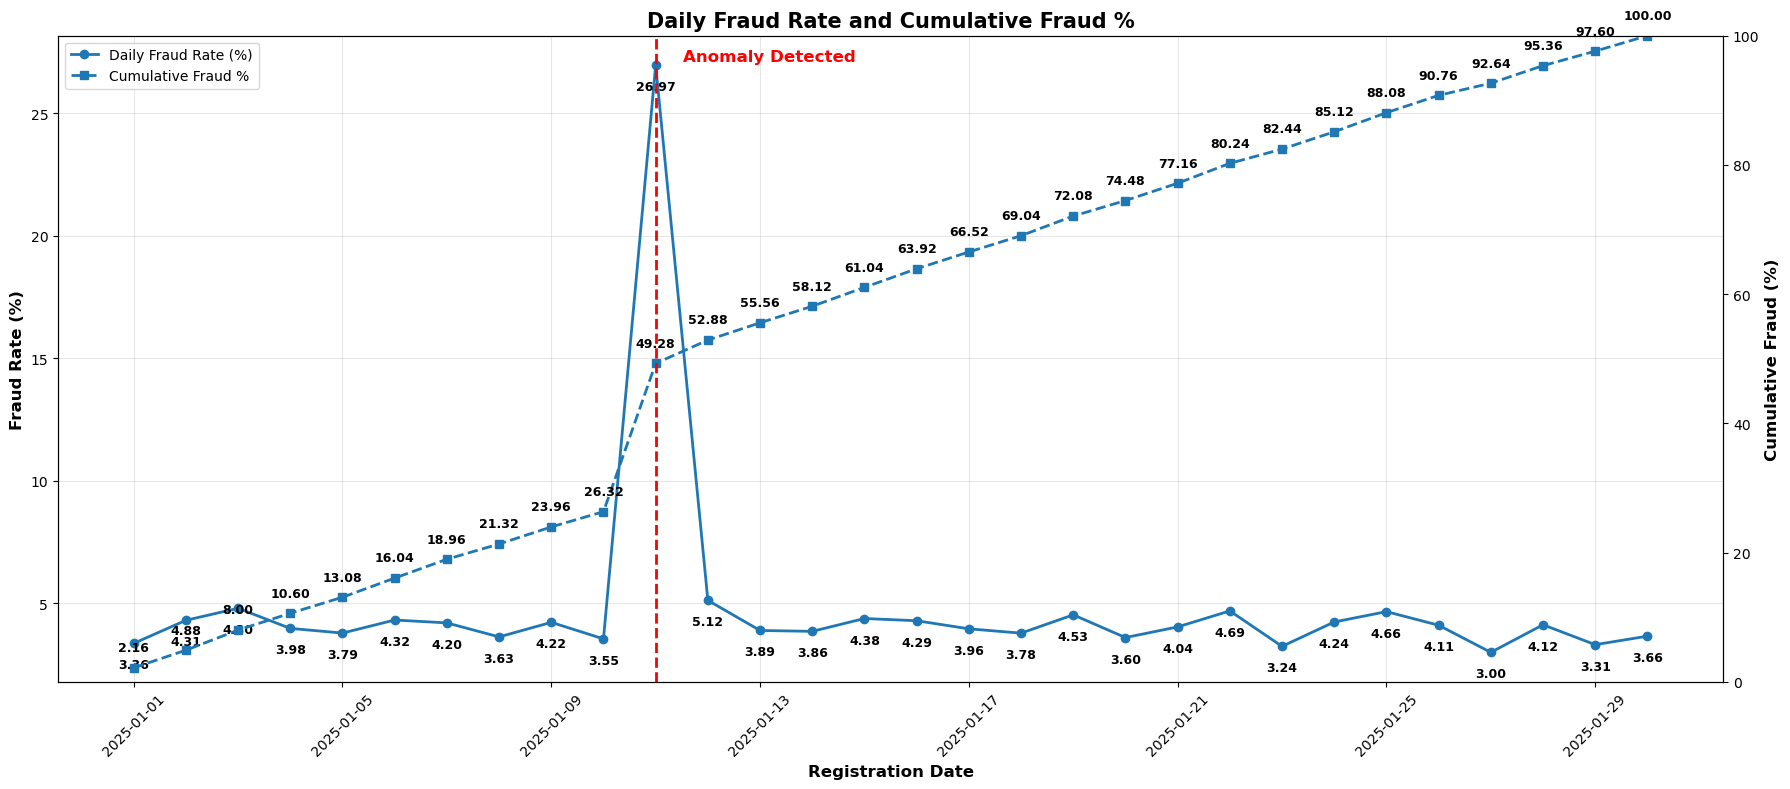

In [32]:
# Plot
fig, ax1 = plt.subplots(figsize=(18, 8))

# Daily Fraud Rate
ax1.plot(
    daily_stats['registration_date'],
    daily_stats['fraud_rate'],
    marker='o',
    linewidth=2,
    label='Daily Fraud Rate (%)'
)

ax1.set_ylabel(
    'Fraud Rate (%)',
    fontsize=12,
    fontweight='bold'
)

ax1.set_xlabel(
    'Registration Date',
    fontsize=12,
    fontweight='bold'
)

ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3)

# Daily Fraud Rate labels
for x, y in zip(
    daily_stats['registration_date'],
    daily_stats['fraud_rate']
):
    ax1.annotate(
        f'{y:.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, -18),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Cumulative Fraud %
ax2 = ax1.twinx()

ax2.plot(
    daily_stats['registration_date'],
    daily_stats['cum_fraud_pct'],
    linestyle='--',
    marker='s',
    linewidth=2,
    label='Cumulative Fraud %'
)

ax2.set_ylabel(
    'Cumulative Fraud (%)',
    fontsize=12,
    fontweight='bold'
)

ax2.set_ylim(0, 100)

# Cumulative Fraud % labels
for x, y in zip(
    daily_stats['registration_date'],
    daily_stats['cum_fraud_pct']
):
    ax2.annotate(
        f'{y:.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    fontsize=10
)

plt.title(
    'Daily Fraud Rate and Cumulative Fraud %',
    fontsize=15,
    fontweight='bold'
)
plt.axvline(
    x=pd.to_datetime('2025-01-11'),
    color='red',
    linestyle='--',
    linewidth=2
)


ax1.annotate(
    'Anomaly Detected',
    (pd.to_datetime('2025-01-11'), 26),
    xytext=(20,20),
    textcoords='offset points',
    fontsize=12,
    color='red',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

### From above graph we can cleary see that almost 25% fraud has been happend on a single day.

In [36]:
filtered_df = df
filtered_df['hour_of_day'] = (
    filtered_df['registration_timestamp']
    .dt.hour
)

hour_pattern = (
    filtered_df
    .groupby('hour_of_day')
    .agg(
        total_users=('is_fraud', 'count'),
        fraud_users=('is_fraud', 'sum')
    )
)

hour_pattern['fraud_rate'] = (
    hour_pattern['fraud_users']
    / hour_pattern['total_users']
) * 100

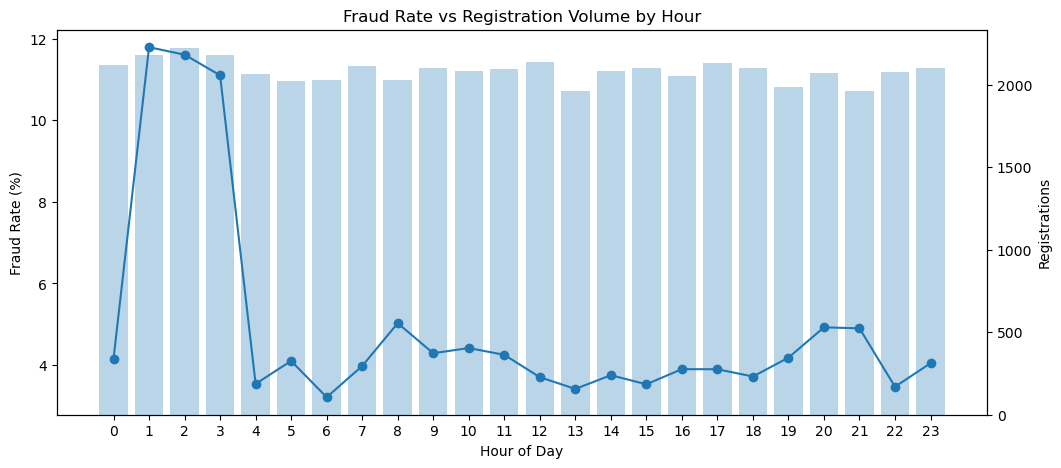

In [37]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    hour_pattern.index,
    hour_pattern['fraud_rate'],
    marker='o',
    label='Fraud Rate (%)'
)
ax1.set_ylabel('Fraud Rate (%)')

ax2 = ax1.twinx()

ax2.bar(
    hour_pattern.index,
    hour_pattern['total_users'],
    alpha=0.3,
    label='Registrations'
)
ax2.set_ylabel('Registrations')

ax1.set_xlabel('Hour of Day')
ax1.set_xticks(range(24))
ax1.set_title('Fraud Rate vs Registration Volume by Hour')

plt.show()

### Hourly Fraud Pattern Analysis

Hourly analysis revealed a clear concentration of fraudulent activity during the **01:00 AM – 03:00 AM** window, where fraud rates exceeded **11%**, compared to the typical **3–5%** observed during most other hours.


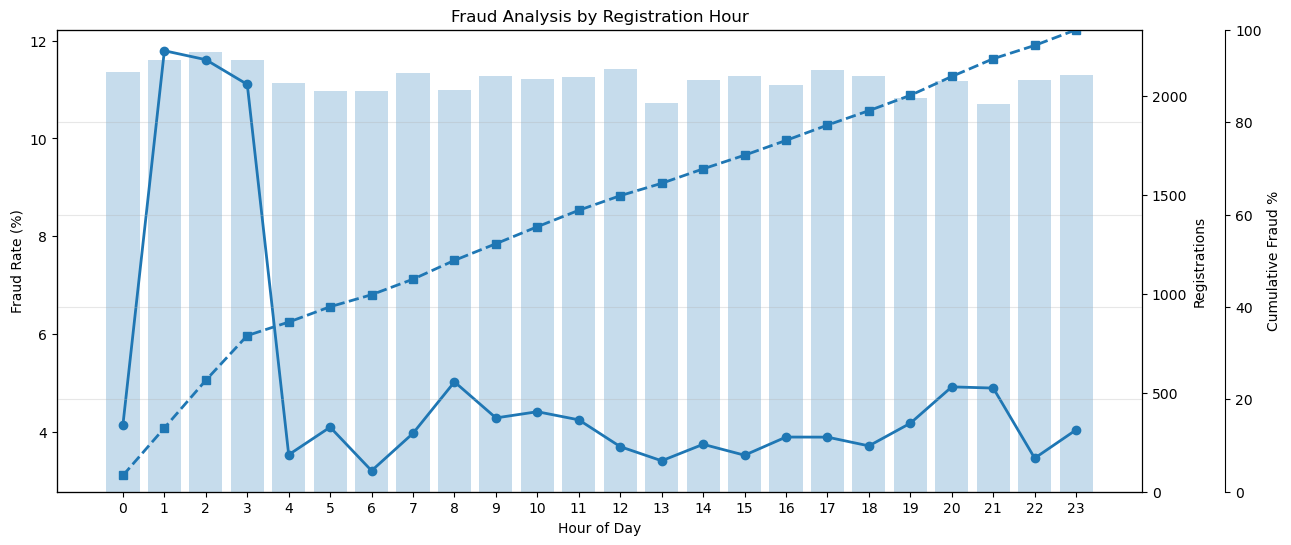

In [72]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Fraud rate line
ax1.plot(
    hour_pattern.index,
    hour_pattern['fraud_rate'],
    marker='o',
    linewidth=2,
    label='Fraud Rate (%)'
)

ax1.set_ylabel('Fraud Rate (%)')
ax1.set_xlabel('Hour of Day')
ax1.set_xticks(range(24))

# Registration volume bars
ax2 = ax1.twinx()

ax2.bar(
    hour_pattern.index,
    hour_pattern['total_users'],
    alpha=0.25,
    label='Registrations'
)

ax2.set_ylabel('Registrations')

# Third axis for cumulative fraud %
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

ax3.plot(
    hour_pattern.index,
    hour_pattern['cum_fraud_pct'],
    linestyle='--',
    linewidth=2,
    marker='s',
    label='Cumulative Fraud %'
)

ax3.set_ylabel('Cumulative Fraud %')
ax3.set_ylim(0, 100)

plt.title('Fraud Analysis by Registration Hour')
plt.grid(True, alpha=0.3)

plt.show()

#### ~40% of fraudelent activities happed in mid-night (0AM - 4AM)

### Detecting Similar Anomalies Without Fraud Labels

In a real-world scenario where fraud labels are unavailable, anomalies can be detected by monitoring registration patterns and identifying unusual deviations from historical behavior.

Potential approaches include:

1. **Statistical Thresholding**
   - Track daily or hourly registration metrics such as registration count, registration rate, or fraud-risk proxy metrics.
   - Flag periods where values exceed a threshold (e.g., Mean ± 3 Standard Deviations or IQR-based thresholds).
   - In this dataset, the spike observed on **10-Jan-2025** would have been automatically flagged as an outlier.

2. **Unsupervised Machine Learning**
   - Algorithms such as **Isolation Forest**, **Local Outlier Factor (LOF)**, or **DBSCAN** can identify abnormal registration periods without requiring fraud labels.
   - Features may include registration volume, registration hour distribution, device usage, email domain distribution, and registration duration.
   - These algorithms do not require balanced classes because they are unsupervised methods. However, they assume anomalies are rare and distinct from normal behavior

3. **Behavioral Drift Monitoring**
   - Continuously monitor shifts in user characteristics (e.g., email domains, device types, registration hours).
   - Significant deviations from historical distributions can indicate emerging fraudulent activity.

### Recommended Approach

For this use case, **Unsupervised Machine Learning** approach would be effective. These methods can identify abnormal registration spikes and unusual behavioral patterns without relying on labeled fraud data, enabling earlier detection of suspicious activity.

## Miscellaneous - Variable Level Deep Dive

In [41]:
education_analysis = (
    df.groupby('education_level')
      .agg(
          total_users=('is_fraud', 'count'),
          fraud_users=('is_fraud', 'sum')
      )
      .reset_index()
)

education_analysis['fraud_rate'] = (
    education_analysis['fraud_users']
    / education_analysis['total_users']
) * 100

education_analysis = education_analysis.sort_values(
    'fraud_rate',
    ascending=False
)

#print(education_analysis)

  education_level  total_users  fraud_users  fraud_rate
3             PhD         3565         1203   33.744741
2         Masters         3147          764   24.277089
0       Bachelors        19322          275    1.423248
1     High School        19071          127    0.665933


In [42]:
overall_fraud_rate = df['is_fraud'].mean() * 100

education_analysis['fraud_lift'] = (
    education_analysis['fraud_rate']
    / overall_fraud_rate
)

#print(education_analysis)

  education_level  total_users  fraud_users  fraud_rate  fraud_lift
3             PhD         3565         1203   33.744741    6.748948
2         Masters         3147          764   24.277089    4.855418
0       Bachelors        19322          275    1.423248    0.284650
1     High School        19071          127    0.665933    0.133187


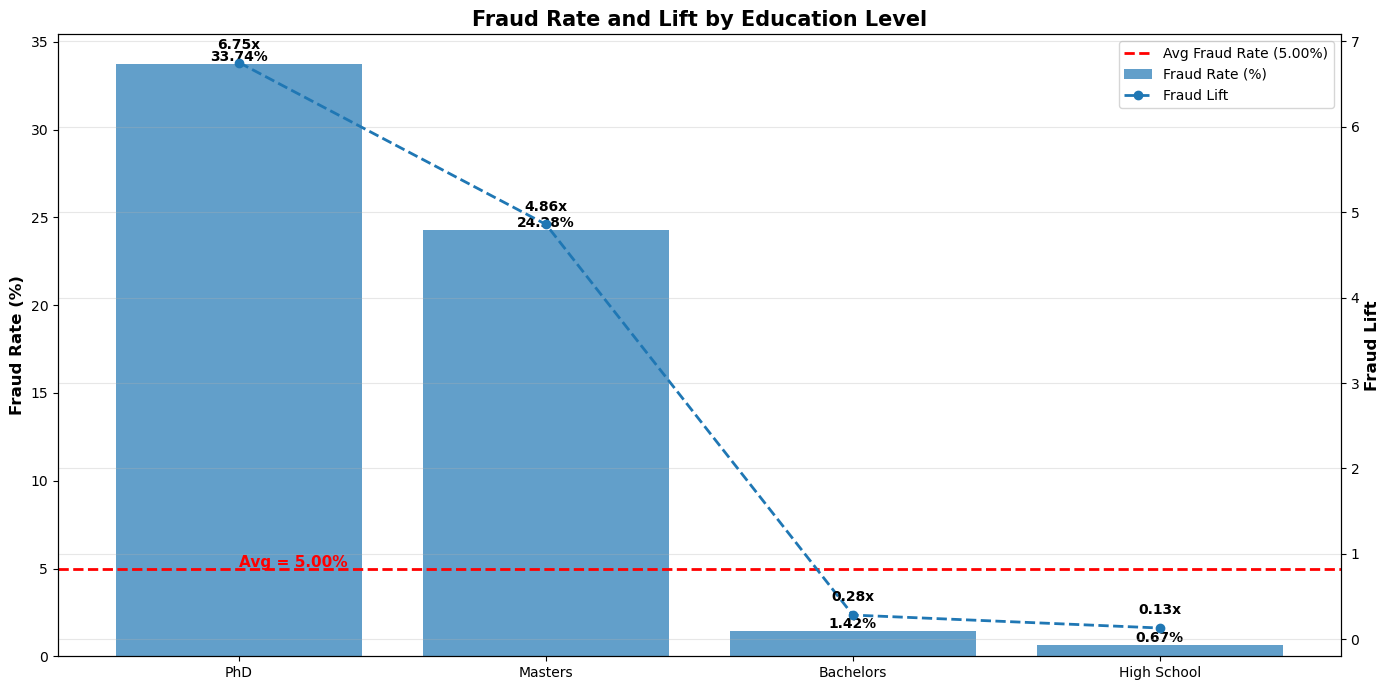

In [43]:
# Overall fraud rate
overall_fraud_rate = df['is_fraud'].mean() * 100

# Fraud lift
education_analysis['fraud_lift'] = (
    education_analysis['fraud_rate']
    / overall_fraud_rate
)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Fraud Rate Bars
bars = ax1.bar(
    education_analysis['education_level'],
    education_analysis['fraud_rate'],
    alpha=0.7,
    label='Fraud Rate (%)'
)

# Fraud Rate Labels
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Average Fraud Rate Line
ax1.axhline(
    y=overall_fraud_rate,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Avg Fraud Rate ({overall_fraud_rate:.2f}%)'
)

# Average Fraud Rate Label
ax1.text(
    0,
    overall_fraud_rate + 0.1,
    f'Avg = {overall_fraud_rate:.2f}%',
    color='red',
    fontsize=11,
    fontweight='bold'
)

ax1.set_ylabel(
    'Fraud Rate (%)',
    fontsize=12,
    fontweight='bold'
)

# Fraud Lift Line
ax2 = ax1.twinx()

ax2.plot(
    education_analysis['education_level'],
    education_analysis['fraud_lift'],
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Fraud Lift'
)

# Lift Labels
for x, y in zip(
    education_analysis['education_level'],
    education_analysis['fraud_lift']
):
    ax2.annotate(
        f'{y:.2f}x',
        (x, y),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax2.set_ylabel(
    'Fraud Lift',
    fontsize=12,
    fontweight='bold'
)

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.title(
    'Fraud Rate and Lift by Education Level',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Fraud Rate by Education Level

- Fraud rates vary substantially across education levels, indicating that **education is a potentially informative feature** for fraud detection.
- Users with a **PhD** exhibit the highest fraud rate (**33.74%**), corresponding to a **6.75× fraud lift** compared to the overall average fraud rate of **5.00%**.
- **Master's** degree holders also show a significantly elevated fraud rate (**24.28%**) with a **4.86× fraud lift**, suggesting they are disproportionately represented among fraudulent users.
- In contrast, users with a **Bachelor's** degree (**1.42%**, **0.28× lift**) and **High School** education (**0.67%**, **0.13× lift**) have fraud rates well below the dataset average.

**Conclusion:**  
Education level appears to be a strong predictor of fraud risk in this dataset, with PhD and Master's categories exhibiting markedly higher fraud concentrations.

In [44]:
job_title_analysis = (
    df.groupby('job_title')
      .agg(
          total_users=('is_fraud', 'count'),
          fraud_users=('is_fraud', 'sum')
      )
      .reset_index()
)

job_title_analysis['fraud_rate'] = (
    job_title_analysis['fraud_users']
    / job_title_analysis['total_users']
) * 100

overall_fraud_rate = df['is_fraud'].mean() * 100

job_title_analysis['fraud_lift'] = (
    job_title_analysis['fraud_rate']
    / overall_fraud_rate
)

job_title_analysis = job_title_analysis.sort_values(
    'fraud_lift',
    ascending=True
)

#print(job_title_analysis)

   job_title  total_users  fraud_users  fraud_rate  fraud_lift
4  Mid-Level        19258          192    0.996988    0.199398
2     Junior        14365          183    1.273930    0.254786
3    Manager        10385          929    8.945595    1.789119
0        CEO         2994          580   19.372077    3.874415
1   Director         2998          616   20.547031    4.109406


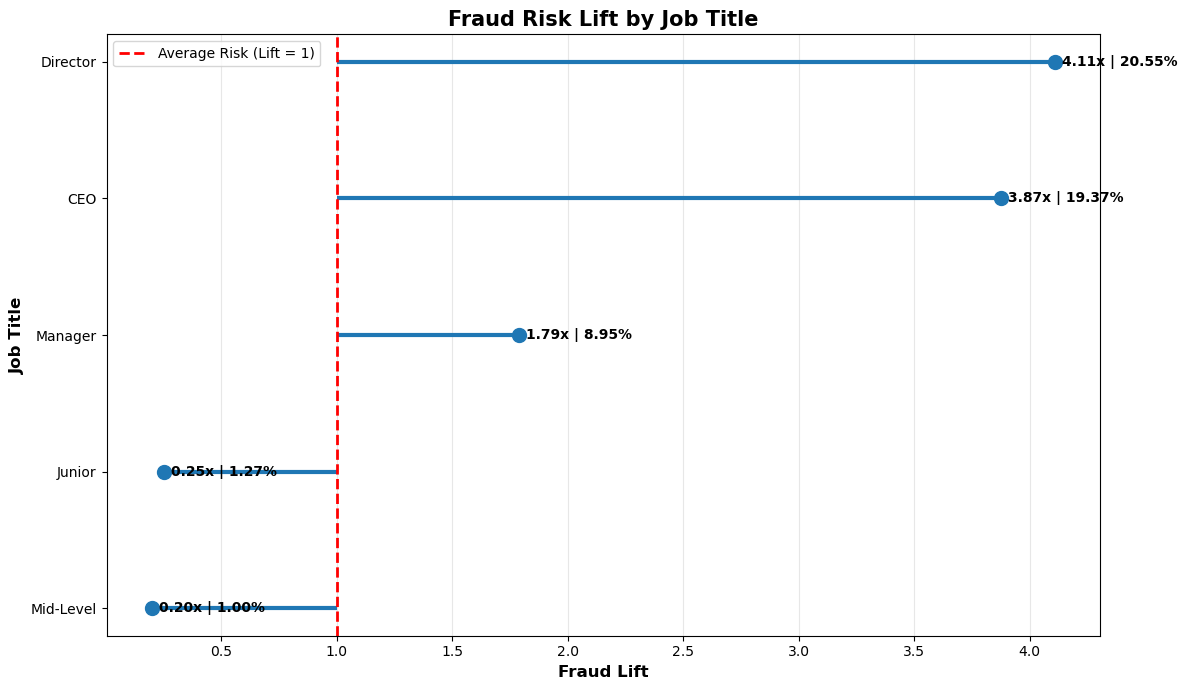

In [45]:
plt.figure(figsize=(12,7))

# Horizontal lines
plt.hlines(
    y=job_title_analysis['job_title'],
    xmin=1,
    xmax=job_title_analysis['fraud_lift'],
    linewidth=3
)

# Dots
plt.plot(
    job_title_analysis['fraud_lift'],
    job_title_analysis['job_title'],
    'o',
    markersize=10
)

# Average risk line
plt.axvline(
    x=1,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Risk (Lift = 1)'
)

# Labels
for x, y, rate in zip(
    job_title_analysis['fraud_lift'],
    job_title_analysis['job_title'],
    job_title_analysis['fraud_rate']
):
    plt.text(
        x + 0.03,
        y,
        f'{x:.2f}x | {rate:.2f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Fraud Risk Lift by Job Title',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Fraud Lift',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Job Title',
    fontsize=12,
    fontweight='bold'
)

plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Fraud Risk by Job Title

- Fraud risk varies considerably across job titles, indicating that **job title is a potentially informative feature** for identifying high-risk users.
- Users with **Director** (**20.55% fraud rate, 4.11× lift**) and **CEO** (**19.37% fraud rate, 3.87× lift**) titles exhibit the highest fraud rates, making them substantially more likely to be fraudulent than the average user.
- **Managers** also show an elevated fraud risk (**8.95% fraud rate, 1.79× lift**), although the increase is less pronounced.
- In contrast, **Junior** (**1.27% fraud rate, 0.25× lift**) and **Mid-Level** (**1.00% fraud rate, 0.20× lift**) users have fraud rates well below the overall average, suggesting they are comparatively lower-risk groups.

**Conclusion:**  
Job title appears to be a valuable predictor of fraud risk, with senior executive titles (Director and CEO) exhibiting significantly higher fraud concentrations.

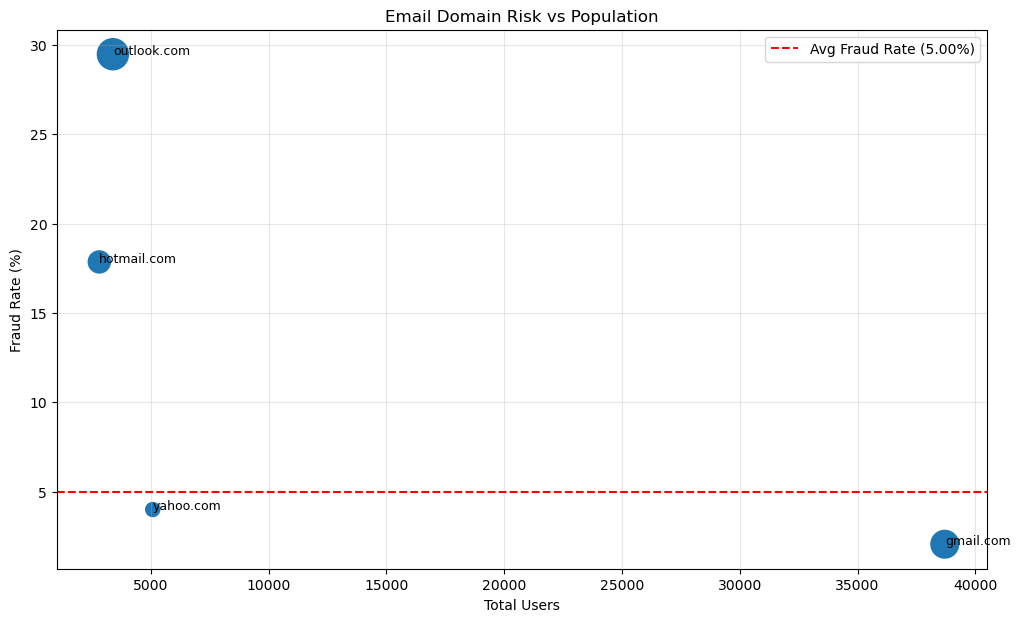

In [46]:
email_analysis = (
    df.groupby('email_domain')
      .agg(
          total_users=('is_fraud', 'count'),
          fraud_users=('is_fraud', 'sum')
      )
      .reset_index()
)

email_analysis['fraud_rate'] = (
    email_analysis['fraud_users']
    / email_analysis['total_users']
) * 100

overall_fraud_rate = df['is_fraud'].mean() * 100

# Keep top domains by volume
email_analysis = email_analysis.nlargest(15, 'total_users')

plt.figure(figsize=(12,7))

plt.scatter(
    email_analysis['total_users'],
    email_analysis['fraud_rate'],
    s=email_analysis['fraud_users']*0.5
)

for _, row in email_analysis.iterrows():
    plt.annotate(
        row['email_domain'],
        (row['total_users'], row['fraud_rate']),
        fontsize=9
    )

plt.axhline(
    overall_fraud_rate,
    color='red',
    linestyle='--',
    label=f'Avg Fraud Rate ({overall_fraud_rate:.2f}%)'
)

plt.xlabel('Total Users')
plt.ylabel('Fraud Rate (%)')
plt.title('Email Domain Risk vs Population')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Fraud Risk by Email Domain

- Fraud rates differ substantially across email domains, suggesting that **email domain is a valuable indicator of fraud risk**.
- Users registering with **outlook.com** exhibit the highest fraud rate (approximately **29%**), followed by **hotmail.com** (approximately **18%**), both significantly exceeding the overall average fraud rate of **5.00%**.
- In contrast, **gmail.com**, despite representing the largest share of users, has a fraud rate of only **~1.5%**, well below the dataset average.
- **yahoo.com** users show a fraud rate of approximately **4%**, which is slightly below the overall average.

**Conclusion:**  
The analysis indicates that certain email domains, particularly **outlook.com** and **hotmail.com**, are associated with a substantially higher concentration of fraudulent users. Conversely, **gmail.com** has the largest user population while exhibiting the lowest fraud rate, suggesting it is comparatively lower risk. However, email domain should not be used as a standalone fraud indicator; instead, it should be combined with behavioral, temporal, and demographic features to improve model robustness and avoid bias.

In [1]:
# age_analysis = (
#     df.groupby('age_bucket')
#       .agg(
#           total_users=('is_fraud', 'count'),
#           fraud_users=('is_fraud', 'sum')
#       )
#       .reset_index()
# )

# age_analysis['fraud_rate'] = (
#     age_analysis['fraud_users']
#     / age_analysis['total_users']
# ) * 100

# overall_fraud_rate = df['is_fraud'].mean() * 100

# age_analysis['fraud_lift'] = (
#     age_analysis['fraud_rate']
#     / overall_fraud_rate
# )

# # Pareto contribution
# age_analysis = age_analysis.sort_values(
#     'fraud_users',
#     ascending=False
# )

# age_analysis['fraud_contribution_pct'] = (
#     age_analysis['fraud_users']
#     / age_analysis['fraud_users'].sum()
# ) * 100

# age_analysis['cumulative_contribution_pct'] = (
#     age_analysis['fraud_contribution_pct']
#     .cumsum()
# )

# #print(age_analysis.round(2))

In [2]:
# fig, ax1 = plt.subplots(figsize=(8,5))

# bars = ax1.bar(
#     age_analysis['age_bucket'],
#     age_analysis['fraud_users']
# )

# # Fraud counts
# for bar in bars:
#     h = bar.get_height()
#     ax1.text(
#         bar.get_x() + bar.get_width()/2,
#         h,
#         f'{int(h)}',
#         ha='center',
#         va='bottom',
#         fontsize=9
#     )

# ax1.set_ylabel('Fraud Users')

# # Cumulative %
# ax2 = ax1.twinx()

# ax2.plot(
#     age_analysis['age_bucket'],
#     age_analysis['cumulative_contribution_pct'],
#     marker='o',
#     linestyle='--',
#     linewidth=2
# )

# for x, y in zip(
#     age_analysis['age_bucket'],
#     age_analysis['cumulative_contribution_pct']
# ):
#     ax2.annotate(
#         f'{y:.1f}%',
#         (x, y),
#         textcoords='offset points',
#         xytext=(0,10),
#         ha='center'
#     )

# ax2.set_ylabel('Cumulative Contribution (%)')
# ax2.set_ylim(0, 100)

# plt.title(
#     'Pareto Analysis of Fraud by Age Bucket',
#     fontsize=14,
#     fontweight='bold'
# )

# plt.tight_layout()
# plt.show()

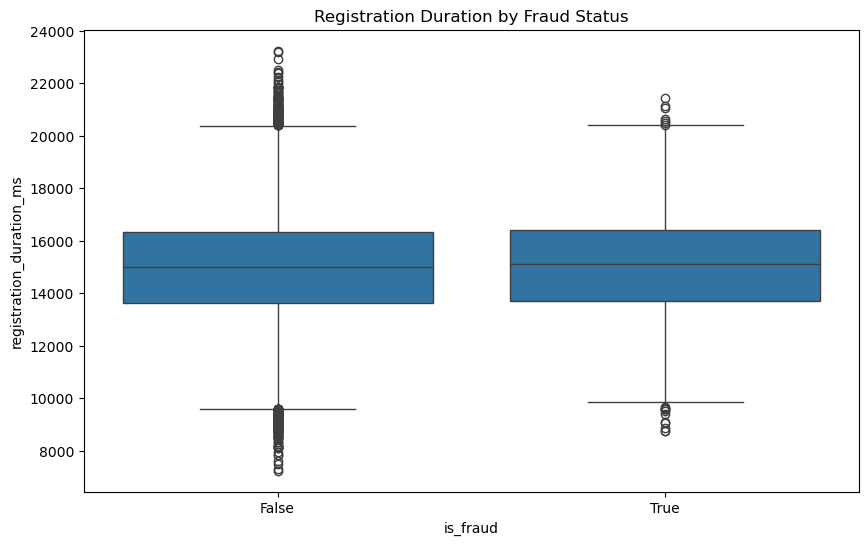

In [49]:

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='registration_duration_ms'
)

plt.title('Registration Duration by Fraud Status')
plt.show()

In [50]:
fraud = df[df['is_fraud']==1]['registration_duration_ms']
non_fraud = df[df['is_fraud']==0]['registration_duration_ms']

t_stat, p_value = ttest_ind(
    fraud,
    non_fraud,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.6956502713082182
P-value: 0.09006477618698909


### Registration Duration non-fraudulen vs Fraud Status

- The boxplots show that the distribution of **registration duration** is highly similar for both fraudulent and non-fraudulent users.
- Both groups have comparable **medians**, **interquartile ranges (IQRs)**, and a similar spread of outliers.
- A Welch's t-test produced a **high p-value (p > 0.05)**, indicating that the difference in mean registration duration between the two groups is **not statistically significant**.

**Conclusion:**  
Registration duration does **not** appear to be a meaningful discriminator between fraudulent and legitimate users. Based on both the visual inspection and statistical tests, this feature provides little predictive value on its own and is unlikely to improve fraud detection without being combined with other behavioral or temporal features.